<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 165 &middot; Capstone 6 &middot; Repeated-Measures ANOVA</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Does Cognitive Training Keep Working?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">The same participants, assessed four times over twelve weeks. Repeated measures buy power, but they bring a new assumption, sphericity, and a new bias risk, the people who drop out. A full framework pass on a within-subject design with more than two conditions.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, AMBER, DARK, BL, RD, GR, MUT = "#b45309", "#d97706", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
TP = ["Baseline","Week 4","Week 8","Week 12"]

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-cognitive-training-over-time.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="assessments")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="assessments")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 165 rows


,subject_id,timepoint,cognitive_score
0,P300,Baseline,50.0
1,P300,Week 4,50.0
2,P300,Week 8,57.3
3,P300,Week 12,43.1
4,P301,Baseline,51.5


## Step 1 &middot; Goal and hypotheses
A twelve-week cognitive-training program assessed the same participants at four points: **Baseline, Week 4, Week 8, and Week 12**. The question is whether scores change over the course of the program, and if so, when the change happens.

Because every participant is measured at all four timepoints, the four columns are linked person by person.
- **H&#8320; (null):** the mean cognitive score is the same at all four timepoints.
- **H&#8321; (alternative):** at least one timepoint differs from the others.
- **&#945; = 0.05.**

This is the same structure as the one-way ANOVA in [Capstone 5](../../capstone-teaching-methods-exam-scores.html), with one crucial difference: the groups are not independent. They are the same people, four times over.

## Step 2 &middot; Know the data types
The outcome, `cognitive_score`, is **continuous**. The condition, `timepoint`, is a **within-subject factor with four levels**, and it is ordered in time. `subject_id` links the four measurements belonging to one person. A continuous outcome measured repeatedly on the same subjects across three or more conditions is the home of the **repeated-measures ANOVA**.

In [2]:
print(raw.dtypes)
print("\nrows per timepoint (raw):")
print(raw.timepoint.value_counts().reindex(TP).to_string())
print("\nassessments per participant (raw):")
print(raw.groupby("subject_id").size().value_counts().sort_index().to_string())

subject_id             str
timepoint              str
cognitive_score    float64
dtype: object

rows per timepoint (raw):
timepoint
Baseline    42
Week 4      43
Week 8      41
Week 12     39

assessments per participant (raw):
2     2
3     1
4    37
5     2


**What this shows.** Most participants have all four assessments, but not all do: some contribute only two or three. That matters more here than in an independent-groups design, because a repeated-measures ANOVA can only use participants with a complete set. Those incomplete records are the attrition problem we return to in Step 12.

## Step 3 &middot; Describe

In [3]:
print("rows:", len(raw), " participants:", raw.subject_id.nunique())
print("\nraw cognitive_score summary:")
print(raw.cognitive_score.describe().round(2).to_string())

rows: 165  participants: 42

raw cognitive_score summary:
count    162.00
mean      55.53
std       14.21
min        0.00
25%       48.82
50%       54.65
75%       63.08
max      155.00


**What this shows.** The score range runs outside the possible 0 to 100 scale, so there are impossible values to clean, and the row count exceeds four times the participant count in places, pointing to duplicate log entries.

## Step 4 &middot; Visualize first
For repeated measures the right first picture shows **each participant's own trajectory**, not just the group averages. A line per person reveals whether people move together or in different directions, which a mean curve alone would hide.

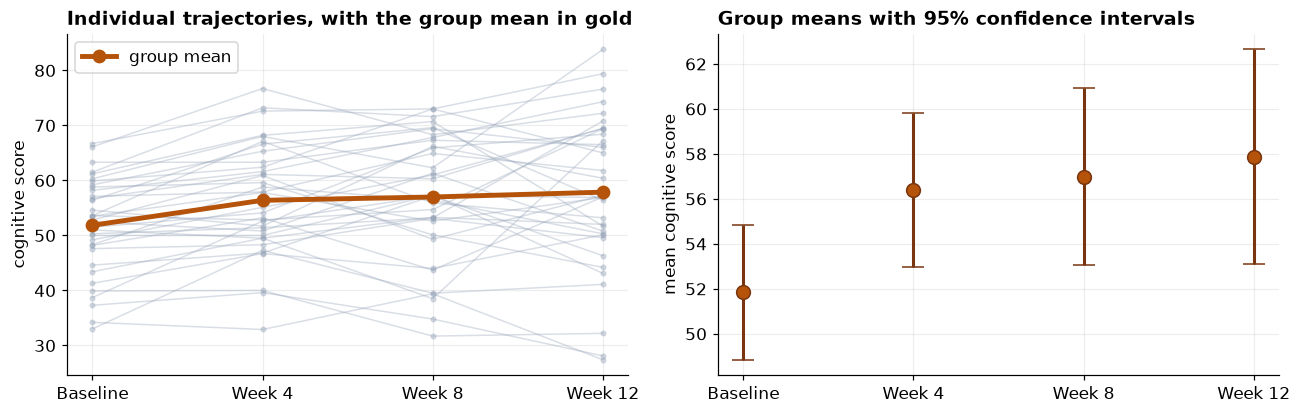

In [4]:
tmp = raw.drop_duplicates().dropna(subset=["cognitive_score"])
tmp = tmp[(tmp.cognitive_score>0) & (tmp.cognitive_score<=100)]
cnt = tmp.groupby("subject_id").timepoint.nunique()
tmp = tmp[tmp.subject_id.isin(cnt[cnt==4].index)]
wide = tmp.pivot(index="subject_id", columns="timepoint", values="cognitive_score")[TP]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
for _, row in wide.iterrows():
    ax[0].plot(TP, row.values, color=MUT, alpha=0.35, lw=1, marker="o", markersize=3)
ax[0].plot(TP, wide.mean().values, color=GOLD, lw=3.2, marker="o", markersize=8, label="group mean")
ax[0].set_ylabel("cognitive score"); ax[0].set_title("Individual trajectories, with the group mean in gold"); ax[0].legend()
means = wide.mean().values
cis = [stats.t.ppf(0.975, len(wide)-1)*wide[t].std(ddof=1)/np.sqrt(len(wide)) for t in TP]
ax[1].errorbar(TP, means, yerr=cis, fmt="o", markersize=9, capsize=7, lw=2,
               color=DARK, markerfacecolor=GOLD, markeredgecolor=DARK)
ax[1].set_ylabel("mean cognitive score"); ax[1].set_title("Group means with 95% confidence intervals")
plt.tight_layout(); plt.show()

**Reading the plot.** The mean climbs from Baseline to Week 4 and then flattens: the Week 8 and Week 12 means sit barely above Week 4. The individual lines add something the means cannot, they **fan out** over time. Participants start close together and end far apart, which is a visual warning that the spread is growing, and that turns out to matter for the sphericity assumption in Step 7.

## Step 5 &middot; Prepare and clean
Repeated measures impose a strict requirement: a participant is usable only with a **complete set of four assessments**. Clean in order: drop **duplicate rows**, drop **missing scores**, drop **impossible scores** (outside 0 to 100), then keep only **complete cases**.

In [5]:
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["cognitive_score"]); a_na = len(df)
bad = df[(df.cognitive_score<=0) | (df.cognitive_score>100)]
df = df[(df.cognitive_score>0) & (df.cognitive_score<=100)]; a_rng = len(df)
n_before = df.subject_id.nunique()
cnt = df.groupby("subject_id").timepoint.nunique()
complete = cnt[cnt==4].index
dropped = sorted(set(df.subject_id) - set(complete))
df = df[df.subject_id.isin(complete)].copy()
print(f"start {len(raw)} rows  ->  dedup {a_dup}  ->  dropna {a_na}  ->  in-range {a_rng}")
print("impossible scores removed:", sorted(bad.cognitive_score.tolist()))
print(f"\nparticipants before completeness filter: {n_before}")
print(f"participants excluded for incomplete data: {len(dropped)}  {dropped}")
print(f"complete-case sample: {df.subject_id.nunique()} participants x 4 timepoints = {len(df)} rows")

start 165 rows  ->  dedup 163  ->  dropna 160  ->  in-range 158
impossible scores removed: [0.0, 155.0]

participants before completeness filter: 42
participants excluded for incomplete data: 7  ['P302', 'P305', 'P309', 'P318', 'P320', 'P325', 'P331']
complete-case sample: 35 participants x 4 timepoints = 140 rows


In [6]:
print(df.groupby("timepoint").cognitive_score.agg(["count","mean","std"]).reindex(TP).round(2).to_string())
wide = df.pivot(index="subject_id", columns="timepoint", values="cognitive_score")[TP]
print("\nmean change from baseline:")
for t in TP[1:]:
    print(f"  {t:9s} {wide[t].mean()-wide['Baseline'].mean():+.2f} points")

           count   mean    std
timepoint                     
Baseline      35  51.84   8.73
Week 4        35  56.38  10.00
Week 8        35  56.99  11.49
Week 12       35  57.87  13.90

mean change from baseline:
  Week 4    +4.54 points
  Week 8    +5.14 points
  Week 12   +6.02 points


**What the numbers say.** Scores rise about 4.5 points from Baseline to Week 4, then add only about half a point by Week 8 and another point by Week 12. Notice also that the standard deviation grows steadily, from about 8.7 at Baseline to about 13.9 at Week 12. That growing spread is exactly what will break sphericity.

## Step 6 &middot; Name the design
One group of participants, one within-subject factor (`timepoint`) with **four levels**. This is a **one-way repeated-measures** design. As in the paired t-test of [Capstone 3](../../capstone-blood-pressure-before-after.html), the repeated structure removes stable person-to-person differences and makes the test far more sensitive than treating the four timepoints as independent groups would.

## Step 7 &middot; Check the assumptions, including a new one
A repeated-measures ANOVA needs approximate **normality**, and then a condition that has no counterpart in the independent-groups case: **sphericity**. Sphericity requires that the variance of the *difference* between any two timepoints is about the same for every pair. When later measurements are more spread out than earlier ones, as here, that condition fails.

variance of the pairwise differences (sphericity wants these roughly equal):
  Baseline  vs Week 4    var =  23.11
  Baseline  vs Week 8    var =  42.91
  Baseline  vs Week 12   var =  94.56
  Week 4    vs Week 8    var =  54.70
  Week 4    vs Week 12   var =  98.32
  Week 8    vs Week 12   var = 109.90

ratio largest/smallest = 4.8x

Mauchly's test: W = 0.477, chi-sq = 24.235, p = 0.0002
SPHERICITY VIOLATED -> a correction is required


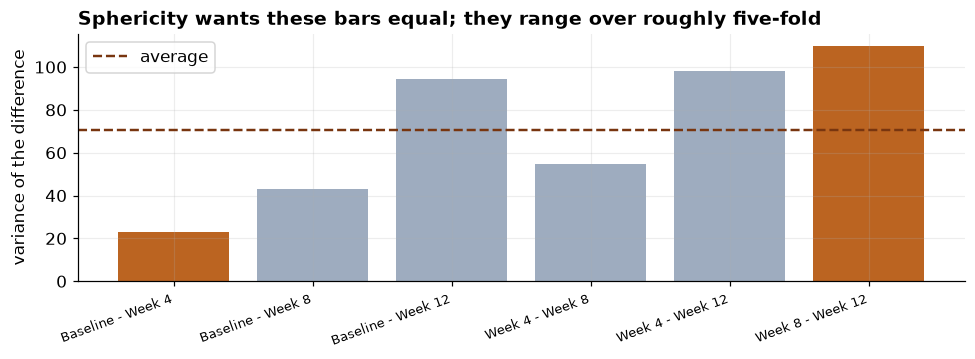

In [7]:
# variance of the difference for every pair of timepoints
pairs = [(a,b) for i,a in enumerate(TP) for b in TP[i+1:]]
print("variance of the pairwise differences (sphericity wants these roughly equal):")
vars_ = {}
for a,b in pairs:
    v = (wide[b]-wide[a]).var(ddof=1); vars_[f"{a} - {b}"] = v
    print(f"  {a:9s} vs {b:8s}  var = {v:6.2f}")
print(f"\nratio largest/smallest = {max(vars_.values())/min(vars_.values()):.1f}x")

sph = pg.sphericity(data=df, dv="cognitive_score", within="timepoint", subject="subject_id")
print(f"\nMauchly's test: W = {sph.W:.3f}, chi-sq = {sph.chi2:.3f}, p = {sph.pval:.4f}")
print("sphericity holds" if sph.spher else "SPHERICITY VIOLATED -> a correction is required")

fig, ax = plt.subplots(figsize=(9, 3.4))
names = list(vars_.keys()); vals = list(vars_.values())
cols_ = [GOLD if v==max(vals) or v==min(vals) else MUT for v in vals]
ax.bar(range(len(vals)), vals, color=cols_, alpha=0.9)
ax.axhline(np.mean(vals), color=DARK, lw=1.6, ls="--", label="average")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8.5)
ax.set_ylabel("variance of the difference")
ax.set_title("Sphericity wants these bars equal; they range over roughly five-fold")
ax.legend()
plt.tight_layout(); plt.show()

**What the diagnostic says.** The pairwise difference variances are nowhere near equal: the largest is several times the smallest, because the later timepoints are much more spread out than the early ones. **Mauchly's test rejects sphericity (p = 0.0002)**, so the uncorrected repeated-measures F test would be too liberal, reporting a smaller p-value than it is entitled to. This is the mirror image of Capstone 2, where a failed variance check sent us to Welch; here a failed sphericity check sends us to a correction.

## Step 8 &middot; Decide, and fix
Sphericity is violated, so we do not abandon the repeated-measures ANOVA; we **correct its degrees of freedom**. The **Greenhouse-Geisser** correction multiplies the degrees of freedom by an estimate, **epsilon**, of how far the data depart from sphericity. Epsilon is 1 when sphericity holds perfectly and shrinks toward 1/(k-1) as the violation worsens; multiplying the degrees of freedom by it makes the test appropriately more conservative. We report the corrected result, and cross-check with the **Friedman** test, the rank-based twin that assumes no sphericity at all.

## Step 9 &middot; Choose the tests
- **Primary:** one-way repeated-measures ANOVA, reported with the **Greenhouse-Geisser corrected** p-value.
- **Post-hoc:** pairwise paired comparisons across the six timepoint pairs, **Holm-corrected** for multiplicity.
- **Robustness check:** Friedman test, the rank-based repeated-measures alternative.
- **Reported alongside:** generalized eta-squared and the effect size for each pairwise contrast.

## Step 10 &middot; Run the tests and report fully

In [8]:
aov = pg.rm_anova(data=df, dv="cognitive_score", within="timepoint", subject="subject_id",
                  detailed=True, correction=True)
print(aov.round(4).to_string())
row = aov.iloc[0]
eps = row["eps"]; df1, df2 = row["DF"], aov.iloc[1]["DF"]
print(f"\nuncorrected : F({df1:.0f}, {df2:.0f}) = {row['F']:.3f},  p = {row['p_unc']:.2e}")
print(f"epsilon (Greenhouse-Geisser) = {eps:.3f}")
print(f"CORRECTED   : F({df1*eps:.2f}, {df2*eps:.2f}) = {row['F']:.3f},  p = {row['p_GG_corr']:.4f}   <- the one we report")
print(f"generalized eta-squared = {row['ng2']:.4f}")

fr = stats.friedmanchisquare(*[wide[t].values for t in TP])
print(f"\nFriedman (robustness): chi-sq = {fr.statistic:.3f}, p = {fr.pvalue:.2e}  -> same conclusion")

      Source         SS   DF        MS       F   p_unc  p_GG_corr     ng2     eps sphericity  W_spher  p_spher
0  timepoint   758.3808    3  252.7936  7.1632  0.0002     0.0012  0.0426  0.7059      False   0.4768   0.0002
1      Error  3599.6617  102   35.2908     NaN     NaN        NaN     NaN     NaN        NaN      NaN      NaN



uncorrected : F(3, 102) = 7.163,  p = 2.06e-04
epsilon (Greenhouse-Geisser) = 0.706
CORRECTED   : F(2.12, 72.00) = 7.163,  p = 0.0012   <- the one we report
generalized eta-squared = 0.0426

Friedman (robustness): chi-sq = 22.743, p = 4.57e-05  -> same conclusion


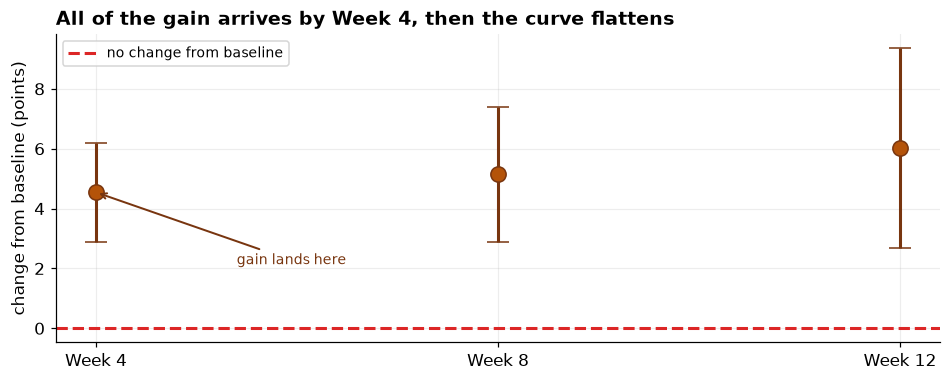

In [9]:
# The shape of the effect: change from baseline, with 95% CIs.
chg = wide[TP[1:]].sub(wide["Baseline"], axis=0)
m = chg.mean().values
ci = [stats.t.ppf(0.975, len(chg)-1)*chg[t].std(ddof=1)/np.sqrt(len(chg)) for t in TP[1:]]
fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.errorbar(TP[1:], m, yerr=ci, fmt="o", markersize=10, capsize=7, lw=2,
            color=DARK, markerfacecolor=GOLD, markeredgecolor=DARK)
ax.axhline(0, color=RD, lw=2, ls="--", label="no change from baseline")
ax.set_ylabel("change from baseline (points)")
ax.set_title("All of the gain arrives by Week 4, then the curve flattens")
ax.annotate("gain lands here", xy=(0, m[0]), xytext=(0.35, m[0]-2.4), fontsize=9, color=DARK,
            arrowprops=dict(arrowstyle="->", color=DARK, lw=1.3))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Reading the output.** The uncorrected test would report p of about 0.0002. After the Greenhouse-Geisser correction, with epsilon = 0.71 shrinking the degrees of freedom from (3, 102) to about (2.12, 72), the p-value rises to **0.0012**. It is still decisively significant, so in this case the correction changes the number without changing the conclusion, which is the outcome we hope for but cannot assume. The Friedman test agrees. Generalized eta-squared is about 0.04, a modest share of the total variation.

In [10]:
ph = pg.pairwise_tests(data=df, dv="cognitive_score", within="timepoint", subject="subject_id",
                       padjust="holm", effsize="hedges")
cols = ["A","B","T","dof","p_unc","p_corr","hedges"]
print(ph[cols].round(4).to_string(index=False))

       A       B       T  dof  p_unc  p_corr  hedges
Baseline Week 12 -3.6643 34.0 0.0008  0.0034 -0.5131
Baseline  Week 4 -5.5876 34.0 0.0000  0.0000 -0.4784
Baseline  Week 8 -4.6447 34.0 0.0000  0.0002 -0.4984
 Week 12  Week 4  0.8847 34.0 0.3825  1.0000  0.1211
 Week 12  Week 8  0.4966 34.0 0.6227  1.0000  0.0682
  Week 4  Week 8 -0.4823 34.0 0.6327  1.0000 -0.0554


**Reading the post-hoc table.** This is where the shape of the effect appears. **Every comparison against Baseline is significant** after Holm correction, and **none of the comparisons among Week 4, Week 8, and Week 12 come close** (all corrected p-values equal 1.00). In other words, essentially all of the measurable gain arrives in the first four weeks and then the curve plateaus. A significant omnibus test told us something changed; the post-hoc tells us it changed early and then stopped.

## Step 11 &middot; Estimate, do not just test
The corrected F-test said scores changed over the twelve weeks. It did not say how much was gained, or by when, and those are the questions a program sponsor is paying for.

In [11]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"{'change from baseline':22s} {'mean':>7s}  {'95% CI':>18s}")
print("-"*52)
for t in TP[1:]:
    d_ = chg[t].values
    moe = stats.t.ppf(0.975, len(d_)-1)*d_.std(ddof=1)/np.sqrt(len(d_))
    print(f"{'Baseline to '+t:22s} {d_.mean():+7.2f}  [{d_.mean()-moe:+6.2f}, {d_.mean()+moe:+6.2f}]")

# The gain that arrives after week 4 is the question the sponsor will ask.
extra = (wide["Week 12"] - wide["Week 4"]).values
moe_e = stats.t.ppf(0.975, len(extra)-1)*extra.std(ddof=1)/np.sqrt(len(extra))
print(f"\n{'Week 4 to Week 12':22s} {extra.mean():+7.2f}  [{extra.mean()-moe_e:+6.2f}, {extra.mean()+moe_e:+6.2f}]")
print("   the interval straddles zero: eight more weeks of training bought nothing detectable")

# An interval for the effect size.
ng2 = float(aov.iloc[0]["ng2"]) if "ng2" in aov.columns else np.nan
g_lo, g_hi, _ = boot_ci(np.arange(len(wide)), lambda idx: (
    lambda w: (lambda ss_e, ss_t: ss_e/ss_t)(
        sum(len(w)*(w[t].mean()-w.values.mean())**2 for t in TP),
        ((w.values - w.values.mean())**2).sum())
)(wide.iloc[idx]))
print(f"\ngeneralized eta-squared {ng2:.4f}   bootstrap 95% CI for the time effect share [{g_lo:.3f}, {g_hi:.3f}]")

change from baseline      mean              95% CI
----------------------------------------------------
Baseline to Week 4       +4.54  [ +2.89,  +6.19]
Baseline to Week 8       +5.14  [ +2.89,  +7.39]
Baseline to Week 12      +6.02  [ +2.68,  +9.36]

Week 4 to Week 12        +1.48  [ -1.92,  +4.89]
   the interval straddles zero: eight more weeks of training bought nothing detectable



generalized eta-squared 0.0426   bootstrap 95% CI for the time effect share [0.020, 0.103]


**Where the gain actually lands.** Every interval from baseline sits clear of zero, so the improvement at each checkpoint is real. The decisive comparison is the last one: from week 4 to week 12 the change is small and its interval straddles zero, which says the extra eight weeks of training bought nothing this study can detect.

That reframes the program question entirely. The post-hoc tests already hinted at it, all three later timepoints being indistinguishable from one another. The interval states it as a magnitude: **the gain arrives by week 4 and then plateaus**, so a sponsor choosing between a four-week and a twelve-week course has an evidence-based answer, and it is not the one the twelve-week price tag assumes.

## Step 12 &middot; Interpret in plain language
Cognitive scores improved over the twelve weeks, and the improvement is statistically solid even after correcting for a violated sphericity assumption (corrected p = 0.001). But the useful finding is the **timing**: participants gained about **4.5 points in the first four weeks** and then essentially stopped, with Weeks 8 and 12 statistically indistinguishable from Week 4. If the program is judged on measurable cognitive gain, the evidence supports the first month and does not support the remaining two.

## Step 13 &middot; Ethics, bias, and limits
- **Attrition is the biggest threat here.** Seven participants were excluded because they lacked a complete set of assessments, and repeated-measures ANOVA requires complete cases. If people dropped out *because* they were not improving, then the analysis retains the responders and quietly overstates the benefit. This is survivorship bias inside a clinical-looking design, and it is not fixed by any test: it is fixed by comparing the dropouts to the completers on baseline scores, and by using a method that can handle incomplete data, such as a linear mixed-effects model.
- **No control group, again.** As in [Capstone 3](../../capstone-blood-pressure-before-after.html), a single arm measured repeatedly cannot separate the program from practice effects. Taking the same style of assessment four times makes people better at the assessment, which looks exactly like a cognitive gain in these data.
- **Regression to the mean.** If participants were enrolled on the basis of low baseline cognition, some rebound would occur with no intervention at all.
- **Do not over-read the plateau.** "No detectable change after Week 4" is not proof that nothing happens later; it may reflect a small effect, a ceiling on the assessment, or insufficient power in a 35-person sample.

---
**From analysis to report.** The notebook carries the evidence: the trajectories, the sphericity diagnostic, the corrected test, the post-hoc structure, and the attrition count. The written reports turn it into a recommendation a program director can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.